# SAMPLES_HE_ACC.csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = "/home/czg/MPHY0035/Data/AA002/SAMPLES_HE_ACC.csv"

cols = ["timestamp_ms", "timestamp_str", "acc_x", "acc_y", "acc_z"]

df = pd.read_csv(
    file_path,
    header=None,
    names=cols,
    low_memory=False
)

print(df.head())
print(df.shape)


    timestamp_ms           timestamp_str  acc_x  acc_y  acc_z
0  1689337494050   14/07/23 12:24:54.050    623   -722  -3709
1  1689337494090   14/07/23 12:24:54.090    667   -688  -3807
2  1689337494130   14/07/23 12:24:54.130    610   -726  -3921
3  1689337494170   14/07/23 12:24:54.170    542   -722  -3922
4  1689337494210   14/07/23 12:24:54.210    734   -720  -3900
(20270176, 5)


In [2]:
df["time"] = pd.to_datetime(df["timestamp_ms"], unit="ms")


In [3]:
print(df.head())

    timestamp_ms           timestamp_str  acc_x  acc_y  acc_z  \
0  1689337494050   14/07/23 12:24:54.050    623   -722  -3709   
1  1689337494090   14/07/23 12:24:54.090    667   -688  -3807   
2  1689337494130   14/07/23 12:24:54.130    610   -726  -3921   
3  1689337494170   14/07/23 12:24:54.170    542   -722  -3922   
4  1689337494210   14/07/23 12:24:54.210    734   -720  -3900   

                     time  
0 2023-07-14 12:24:54.050  
1 2023-07-14 12:24:54.090  
2 2023-07-14 12:24:54.130  
3 2023-07-14 12:24:54.170  
4 2023-07-14 12:24:54.210  


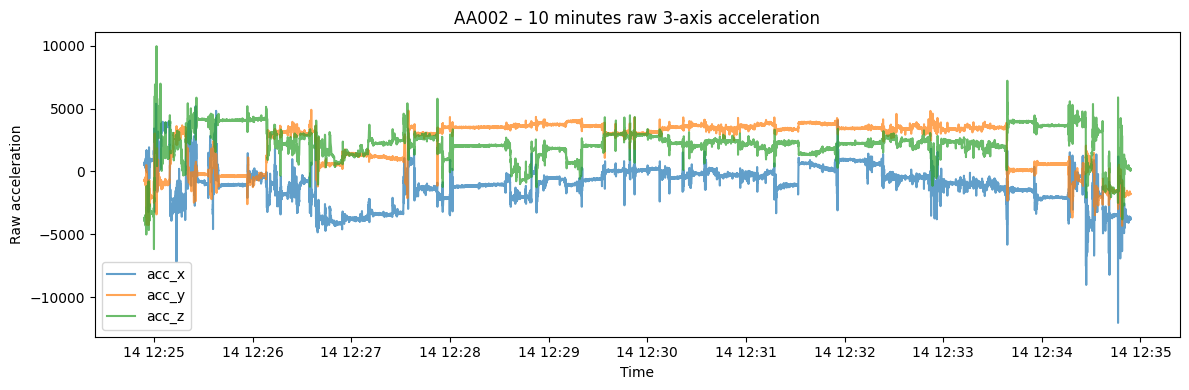

In [4]:
df = df.set_index("time")

start_time = df.index[0]
window = df.loc[start_time : start_time + pd.Timedelta(minutes=10)]

plt.figure(figsize=(12, 4))
plt.plot(window.index, window["acc_x"], label="acc_x", alpha=0.7)
plt.plot(window.index, window["acc_y"], label="acc_y", alpha=0.7)
plt.plot(window.index, window["acc_z"], label="acc_z", alpha=0.7)

plt.legend()
plt.title("AA002 – 10 minutes raw 3-axis acceleration")
plt.xlabel("Time")
plt.ylabel("Raw acceleration")
plt.tight_layout()
plt.show()


In [5]:
df["acc_mag"] = np.sqrt(
    df["acc_x"]**2 +
    df["acc_y"]**2 +
    df["acc_z"]**2
)


In [6]:
acc_10s = df["acc_mag"].resample("10s").mean()


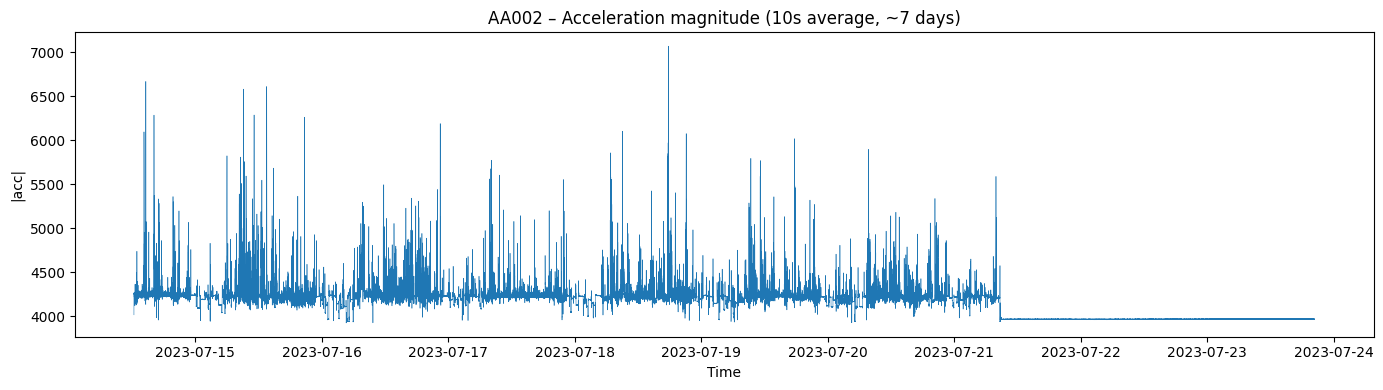

In [7]:
plt.figure(figsize=(14, 4))
plt.plot(acc_10s.index, acc_10s.values, linewidth=0.4)

plt.title("AA002 – Acceleration magnitude (10s average, ~7 days)")
plt.xlabel("Time")
plt.ylabel("|acc|")
plt.tight_layout()
plt.show()


# SAMPLES_Step_count.csv

In [8]:
step_file = "/home/czg/MPHY0035/Data/AA002/SAMPLES_Step_count.csv"

step_cols = ["timestamp_ms", "timestamp_str", "step_count"]

steps = pd.read_csv(
    step_file,
    header=None,
    names=step_cols
)

steps["time"] = pd.to_datetime(steps["timestamp_ms"], unit="ms")
steps = steps.set_index("time")

print(steps.head())
print(steps.shape)


                      timestamp_ms           timestamp_str  step_count
time                                                                  
2023-07-14 12:24:54  1689337494000   14/07/23 12:24:54.000          18
2023-07-14 12:41:00  1689338460000   14/07/23 12:41:00.000          30
2023-07-14 12:44:00  1689338640000   14/07/23 12:44:00.000          46
2023-07-14 12:48:00  1689338880000   14/07/23 12:48:00.000          60
2023-07-14 12:49:00  1689338940000   14/07/23 12:49:00.000          68
(2809, 3)


In [ ]:
steps_raw = steps.copy()

steps_raw["step_diff"] = steps_raw["step_count"].diff()

steps_raw.loc[steps_raw["step_diff"] < 0, "step_diff"] = 0

steps_10s_clean = steps_raw["step_diff"].resample("10s").sum()

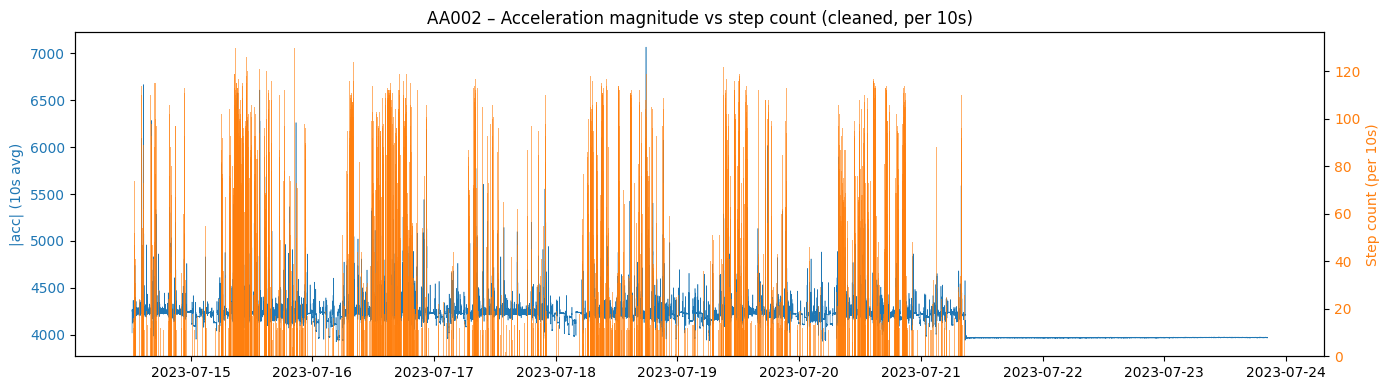

In [10]:
fig, ax1 = plt.subplots(figsize=(14, 4))

ax1.plot(acc_10s.index, acc_10s.values,
         color="tab:blue", linewidth=0.4)
ax1.set_ylabel("|acc| (10s avg)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.bar(
    steps_10s_clean.index,
    steps_10s_clean.values,
    width=0.006,
    color="tab:orange",
    alpha=0.6
)
ax2.set_ylabel("Step count (per 10s)", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

plt.title("AA002 – Acceleration magnitude vs step count (cleaned, per 10s)")
plt.tight_layout()
plt.show()

# annotator.json

In [11]:
import json
import pandas as pd

annot_path = "/home/czg/MPHY0035/Data/AA002/annotator.json"

with open(annot_path, "r") as f:
    annot = json.load(f)

shapes = annot["shapes"]
print(len(shapes))


121


In [12]:
records = []

for s in shapes:
    if s.get("type") != "timerange":
        continue
    if "location" not in s.get("data", {}):
        continue

    records.append({
        "start": pd.to_datetime(s["start"], unit="ms"),
        "end":   pd.to_datetime(s["end"],   unit="ms"),
        "location": s["data"]["location"]
    })

loc_df = pd.DataFrame(records)
print(loc_df.head())


                    start                     end location
0 2023-07-17 23:00:27.038 2023-07-18 07:15:22.841  Bedroom
1 2023-07-16 23:03:22.386 2023-07-17 07:49:09.004  Bedroom
2 2023-07-15 23:28:22.236 2023-07-16 07:48:02.225  Bedroom
3 2023-07-18 22:11:21.993 2023-07-19 10:42:19.317  Bedroom
4 2023-07-19 22:30:33.639 2023-07-20 08:55:09.487  Bedroom


In [13]:
# acc_10s.index is DatetimeIndex（10s）
location_series = pd.Series(index=acc_10s.index, dtype="object")

for _, row in loc_df.iterrows():
    mask = (acc_10s.index >= row["start"]) & (acc_10s.index <= row["end"])
    location_series.loc[mask] = row["location"]

# not covered time in annotation → NaN（Outdoors / Unknown）

In [14]:
df_10s = pd.DataFrame({
    "acc_mag": acc_10s,
    "steps": steps_10s_clean,
    "location": location_series
})

print(df_10s.head())


                         acc_mag  steps location
time                                            
2023-07-14 12:24:50  4018.701585    0.0      NaN
2023-07-14 12:25:00  4235.271664    0.0      NaN
2023-07-14 12:25:10  4265.059210    0.0      NaN
2023-07-14 12:25:20  4230.344927    0.0      NaN
2023-07-14 12:25:30  4243.664293    0.0      NaN


In [15]:
df_10s["location"].value_counts(dropna=False)


location
Bedroom              26358
NaN                  21485
Out                  11630
Other 2               9607
Living                4495
Indoor transition     2888
Unknown               2268
Kitchen               1837
Office                  64
Name: count, dtype: int64

In [16]:
df = df_10s.copy()

df["date"] = df.index.date
df["hour"] = df.index.hour


In [17]:
locations = sorted(df["location"].dropna().unique())
print(locations)


['Bedroom', 'Indoor transition', 'Kitchen', 'Living', 'Office', 'Other 2', 'Out', 'Unknown']


In [18]:
loc_map = {loc: i for i, loc in enumerate(locations)}
df["loc_code"] = df["location"].map(loc_map)


In [19]:
import numpy as np

pivot = (
    df
    .dropna(subset=["loc_code"])
    .groupby(["date", "hour"])["loc_code"]
    .agg(lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else np.nan)
    .unstack()
)

pivot.head()


hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
date,,,,,,,,,,,,,,,,,,,,,
2023-07-14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.0,5.0,5.0,7.0,5.0,5.0,5.0,3.0,3.0,3.0
2023-07-15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,3.0,1.0,...,3.0,3.0,0.0,6.0,6.0,6.0,6.0,6.0,6.0,0.0
2023-07-16,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,5.0,...,2.0,6.0,6.0,6.0,6.0,7.0,7.0,3.0,3.0,0.0
2023-07-17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,...,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,3.0,0.0
2023-07-18,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,6.0,6.0,...,6.0,6.0,6.0,6.0,0.0,0.0,3.0,3.0,0.0,0.0


In [20]:
loc_map

{'Bedroom': 0,
 'Indoor transition': 1,
 'Kitchen': 2,
 'Living': 3,
 'Office': 4,
 'Other 2': 5,
 'Out': 6,
 'Unknown': 7}

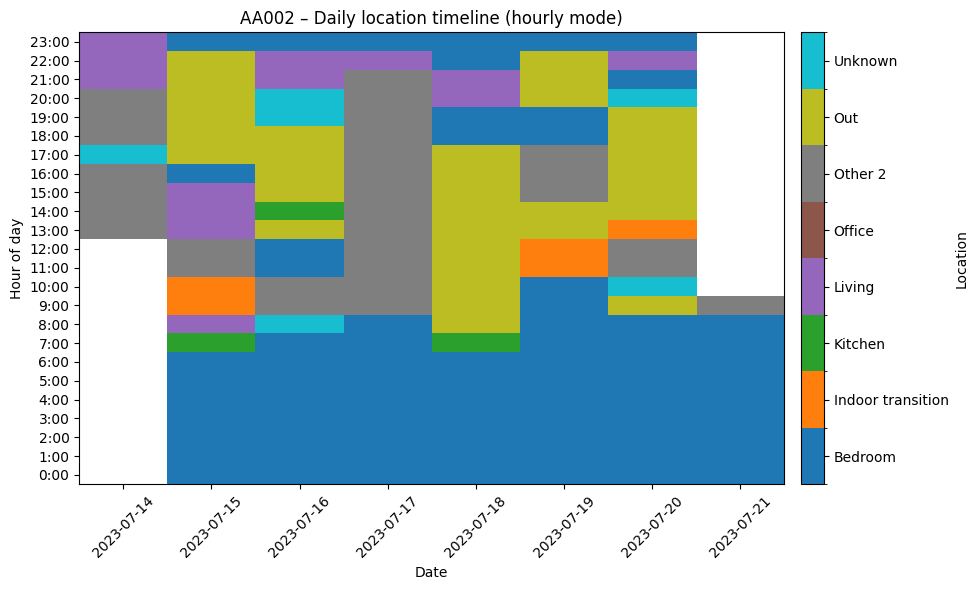

In [21]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

plt.figure(figsize=(10, 6))

n_locs = len(loc_map)
cmap = plt.get_cmap("tab10", n_locs)
bounds = [i - 0.5 for i in range(n_locs + 1)]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

im = plt.imshow(
    pivot.T,
    aspect="auto",
    origin="lower",
    cmap=cmap,
    norm=norm
)

plt.yticks(
    ticks=range(24),
    labels=[f"{h}:00" for h in range(24)]
)

plt.xticks(
    ticks=range(len(pivot.index)),
    labels=pivot.index,
    rotation=45
)

cbar = plt.colorbar(
    im,
    ticks=list(loc_map.values()),
    label="Location",
    pad=0.02
)

cbar.ax.set_yticklabels(list(loc_map.keys()))

plt.clim(-0.5, n_locs - 0.5)

plt.title("AA002 – Daily location timeline (hourly mode)")
plt.xlabel("Date")
plt.ylabel("Hour of day")

plt.tight_layout()
plt.show()


# acc + step count + location

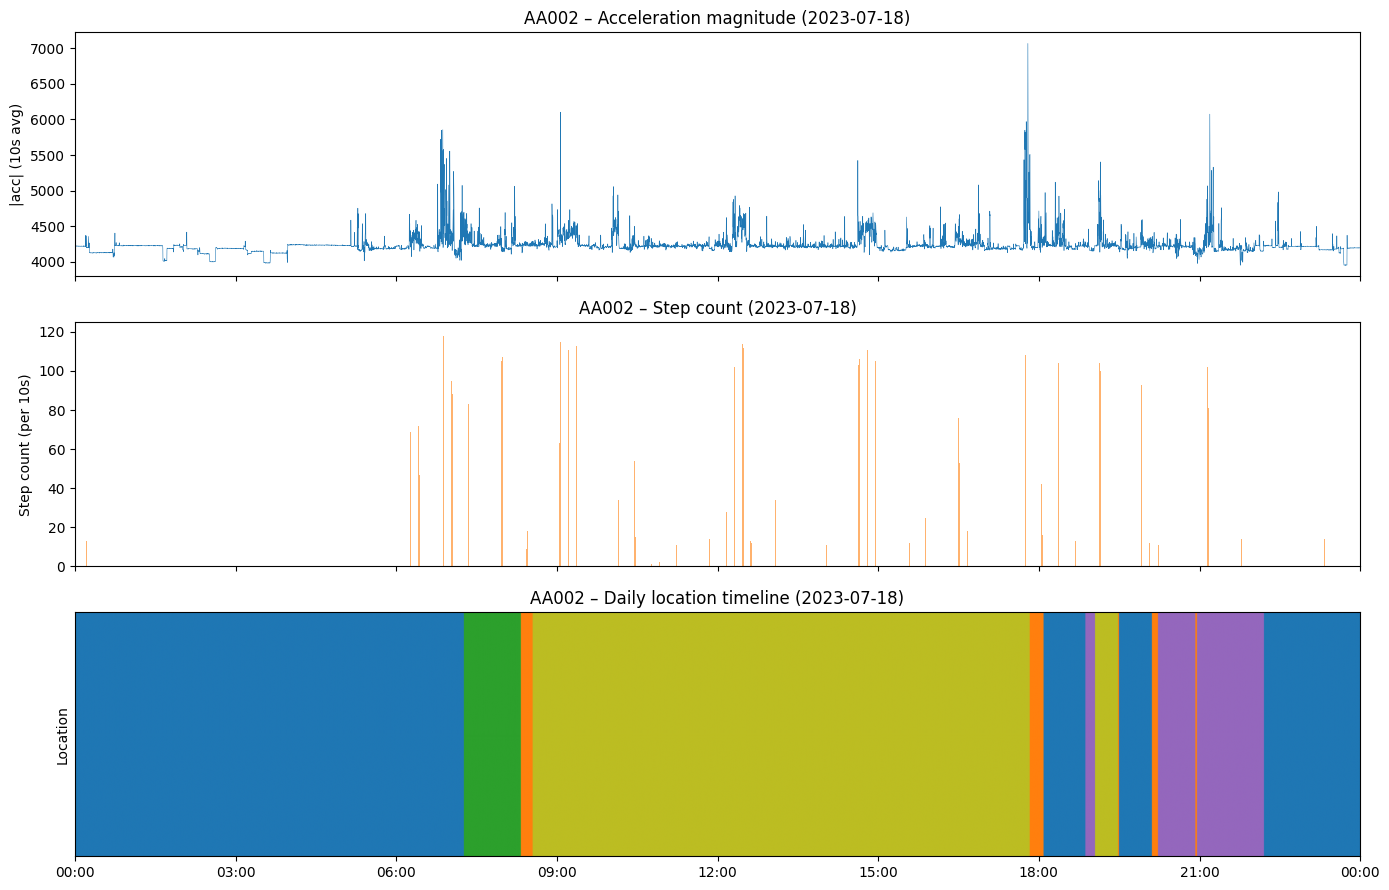

In [23]:
import matplotlib.dates as mdates
import matplotlib.colors as mcolors

# Focus on a single day
start_day = pd.Timestamp("2023-07-18")
end_day = start_day + pd.Timedelta(days=1)

acc_day = acc_10s.loc[start_day:end_day]
steps_day = steps_10s_clean.loc[start_day:end_day]
loc_day = location_series.loc[start_day:end_day]

# Location color mapping
locations_day = sorted(df_10s["location"].dropna().unique())
loc_map_day = {loc: i for i, loc in enumerate(locations_day)}

loc_codes = loc_day.map(loc_map_day).fillna(-1).astype(int)

n_locs = len(loc_map_day)
base = plt.get_cmap("tab10", n_locs)
colors = base(range(n_locs))
missing_color = [[0.85, 0.85, 0.85, 1.0]]
loc_cmap = mcolors.ListedColormap(list(colors) + missing_color)

bounds = [i - 0.5 for i in range(n_locs + 1)] + [n_locs + 0.5]
loc_norm = mcolors.BoundaryNorm(bounds, loc_cmap.N)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

# Acceleration magnitude
ax1.plot(acc_day.index, acc_day.values, linewidth=0.4, color="tab:blue")
ax1.set_ylabel("|acc| (10s avg)")
ax1.set_title("AA002 – Acceleration magnitude (2023-07-18)")

# Step count
bar_width = 10 / 86400  # 10 seconds in days
ax2.bar(
    steps_day.index,
    steps_day.values,
    width=bar_width,
    color="tab:orange",
    alpha=0.6
)
ax2.set_ylabel("Step count (per 10s)")
ax2.set_title("AA002 – Step count (2023-07-18)")

# Location timeline
loc_array = loc_codes.to_numpy()[None, :]
x0 = mdates.date2num(loc_day.index[0])
x1 = mdates.date2num(loc_day.index[-1])

im = ax3.imshow(
    loc_array,
    aspect="auto",
    cmap=loc_cmap,
    norm=loc_norm,
    extent=[x0, x1, 0, 1]
)
ax3.set_yticks([])
ax3.set_ylabel("Location")
ax3.set_title("AA002 – Daily location timeline (2023-07-18)")
ax3.xaxis_date()
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

ax3.set_xlim(start_day, end_day)
'''
cbar = fig.colorbar(
    im,
    ax=ax3,
    ticks=list(loc_map_day.values()),
    pad=0.01
)

cbar.ax.set_yticklabels(list(loc_map_day.keys()))
'''
plt.tight_layout()
plt.show()
